In [948]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [949]:
keras.utils.set_random_seed(42)

In [950]:
df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/heart.csv")
df.shape

(303, 14)

In [951]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [952]:
df.target.value_counts(normalize=True, dropna=False)

target
0    0.726073
1    0.273927
Name: proportion, dtype: float64

In [953]:
categorical_variables = ['sex', 'cp', 'fbs', 'restecg','exang', 'ca', 'thal']
numerics = ['age', 'trestbps','chol', 'thalach', 'oldpeak', 'slope']

In [954]:
df = pd.get_dummies(df, columns=categorical_variables)

In [955]:
df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,63,145,233,150,2.3,3,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,67,160,286,108,1.5,2,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,67,120,229,129,2.6,2,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,37,130,250,187,3.5,3,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,41,130,204,172,1.4,1,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


In [956]:
test_df = df.sample(frac=0.2, random_state=42)
train_df = df.drop(test_df.index)

In [957]:
test_df.shape

(61, 30)

In [958]:
train_df.shape

(242, 30)

In [959]:
means = train_df[numerics].mean()
sd = train_df[numerics].std()

In [960]:
means

age          54.268595
trestbps    131.995868
chol        246.512397
thalach     149.805785
oldpeak       1.032645
slope         1.590909
dtype: float64

In [961]:
train_df[numerics] = (train_df[numerics] - means) / sd

In [962]:
test_df[numerics] = (test_df[numerics] - means) / sd

In [963]:
train_df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,0.963746,0.721939,-0.278690,0.008396,1.083461,2.226814,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,1.405254,1.554681,0.814423,-1.807247,0.399542,0.646494,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,1.405254,-0.665964,-0.361189,-0.899426,1.339930,0.646494,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,-1.906055,-0.110803,0.071931,1.607891,2.109339,2.226814,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,-1.464547,-0.110803,-0.876809,0.959447,0.314052,-0.933825,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


In [964]:
train = train_df.to_numpy()
test = test_df.to_numpy()

In [965]:
train_X = np.delete(train, 6, axis=1)
test_X = np.delete(test, 6, axis=1)

In [966]:
train_X.shape, test_X.shape

((242, 29), (61, 29))

In [967]:
train_y = train[:, 6]
test_y = test[:, 6]

In [968]:
train_y.shape, test_y.shape

((242,), (61,))

In [969]:
num_colums = train_X.shape[1]

# define the input layer
input = keras.Input(shape=(num_colums,))

# feed the input vector to the hidden layer
h = keras.layers.Dense(16, activation='relu', name='Hidden')(input)

h = keras.layers.Dense(8, activation='relu', name='Hidden2')(h)

# feed the output of the hidden layer to the output layer
output = keras.layers.Dense(1, activation='sigmoid', name='Output')(h)

# tell Keras that this (input, output) pair is your model
model = keras.Model(input, output)

In [970]:
model.summary()

Model: "functional_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_31 (InputLayer)     │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden (Dense)                  │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 625 (2.44 KB)

 Trainable params: 625 (2.44 KB)

 Non-trainable params: 0 (0.00 B)

In [971]:
(29 + 1)* 16 + (16 + 1) * 1

497

In [972]:
keras.utils.plot_model(model, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [973]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [974]:
train_X = train_X.astype('float32')
train_y = train_y.astype('float32')

In [975]:
test_X = test_X.astype('float32')
test_y = test_y.astype('float32')

In [976]:
history = model.fit(train_X, train_y, epochs=325, batch_size=40, verbose=1, validation_split=0.2)  

Epoch 1/325
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5751 - loss: 0.6895 - val_accuracy: 0.5510 - val_loss: 0.7017
Epoch 2/325
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6425 - loss: 0.6654 - val_accuracy: 0.6122 - val_loss: 0.6856
Epoch 3/325
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6788 - loss: 0.6430 - val_accuracy: 0.6327 - val_loss: 0.6698
Epoch 4/325
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7098 - loss: 0.6212 - val_accuracy: 0.6735 - val_loss: 0.6537
Epoch 5/325
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7358 - loss: 0.6004 - val_accuracy: 0.6735 - val_loss: 0.6388
Epoch 6/325
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7409 - loss: 0.5803 - val_accuracy: 0.6939 - val_loss: 0.6244
Epoch 7/325
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7513 - loss: 0.5601 - val_accuracy: 0.6939 - val_loss: 0.6096
Epoch 8/325
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7513 - loss: 0.5398 - val_accuracy: 0.6939 - val_loss: 0.5948

In [977]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

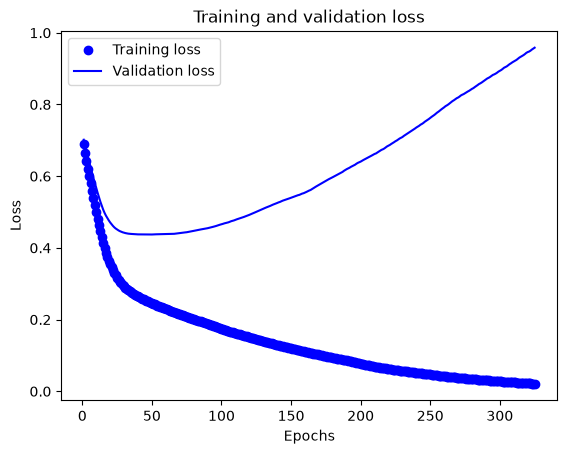

In [978]:
# https://github.com/fchollet/deep-learning-with-python-notebooks/

loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

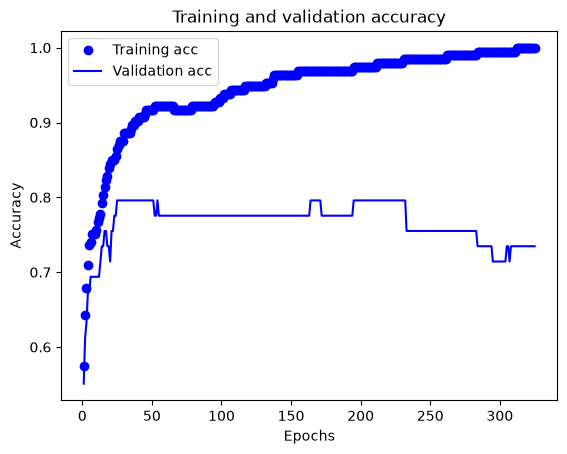

In [979]:
# https://github.com/fchollet/deep-learning-with-python-notebooks/

plt.clf()   # clear figure
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [980]:
model.evaluate(test_X, test_y)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8852 - loss: 0.6499


[0.6498849987983704, 0.8852459192276001]